In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from pathlib import Path

from sklearn.preprocessing import LabelEncoder
from sklearn.preprocessing import StandardScaler

from sklearn.ensemble import RandomForestClassifier

from sklearn.metrics import accuracy_score

In [2]:
PROJECT_ROOT = Path(
    r"C:\Users\armaa\OneDrive\Desktop\TinyML-Vibration-Anomaly-Detection"
)

PROCESSED_PATH = (
    PROJECT_ROOT
    / "data"
    / "processed"
    / "CWRU"
)

FIGURE_PATH = (
    PROCESSED_PATH
    / "figures"
)

FIGURE_PATH.mkdir(
    parents=True,
    exist_ok=True
)

print("Processed path:", PROCESSED_PATH)
print("Figure path:", FIGURE_PATH)

Processed path: C:\Users\armaa\OneDrive\Desktop\TinyML-Vibration-Anomaly-Detection\data\processed\CWRU
Figure path: C:\Users\armaa\OneDrive\Desktop\TinyML-Vibration-Anomaly-Detection\data\processed\CWRU\figures


In [3]:
feature_file = (
    PROCESSED_PATH
    / "cwru_physics_features.csv"
)

feature_df = pd.read_csv(
    feature_file
)

print(
    "Dataset shape:",
    feature_df.shape
)

display(feature_df)

Dataset shape: (17, 16)


,source_file,signal_id,class,RPM,RMS,Variance,Kurtosis,Crest_Factor,Peak_to_Peak,Energy_1x,Energy_2x,Energy_3x,Energy_BPFI,Energy_BPFO,Energy_FTF,Energy_BSF
0,B007_0.mat,X118,Ball,1796.0,0.138266,0.018884,2.964506,3.802842,1.046245,12.651480,7.261748,16.516354,5924.331644,12.313566,1.602576,19.271154
1,B007_1.mat,X119,Ball,1772.0,0.138471,0.019157,2.983638,3.720946,1.030164,4.130463,14.695277,6.011213,1880.497997,5.852975,0.413234,46.279088
2,B007_2.mat,X120,Ball,1748.0,0.144331,0.020808,2.724532,3.461846,0.965839,0.962573,12.849932,6.865564,2830.918487,3.090036,0.337600,54.560167
3,B007_3.mat,X121,Ball,1722.0,0.154805,0.023953,2.832997,4.030328,1.233532,0.316885,14.019952,5.584360,5597.967603,6.028661,0.474728,49.992032
4,IR007_0.mat,X105,Inner Race,1797.0,0.289302,0.083467,5.632106,5.477161,2.794696,4.612868,85.396632,9.398079,9877.105213,6.778110,1.214267,74.754989
5,IR007_1.mat,X106,Inner Race,1772.0,0.293137,0.085896,5.385724,5.392771,2.768219,3.174612,101.021073,11.512352,7110.367942,15.299637,0.245257,41.264131
6,IR007_2.mat,X107,Inner Race,1748.0,0.297810,0.088672,5.536653,5.131425,2.767732,3.295349,70.214556,11.281598,8866.673469,15.063411,0.740351,81.768769
7,IR007_3.mat,X108,Inner Race,1721.0,0.312346,0.097539,5.219968,4.916021,3.037050,7.750201,70.236020,9.112824,3013.363693,5.086434,2.959702,96.861840
8,NORMAL_0.mat,X097,Healthy,1796.0,0.074082,0.005353,2.869599,3.683347,0.520287,309.244831,671.825264,5204.385359,16241.260928,4360.307900,7.644515,3909.052674
9,NORMAL_1.mat,X098,Healthy,NaN,0.065114,0.004120,2.932471,3.498587,0.439344,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [4]:
class_distribution = (
    feature_df["class"]
    .value_counts()
)

print(class_distribution)

class
Healthy       5
Ball          4
Inner Race    4
Outer Race    4
Name: count, dtype: int64


In [5]:
display(
    feature_df[
        [
            "source_file",
            "signal_id",
            "class",
            "RPM"
        ]
    ].sort_values(
        ["class", "source_file", "signal_id"]
    )
)

,source_file,signal_id,class,RPM
0,B007_0.mat,X118,Ball,1796.0
1,B007_1.mat,X119,Ball,1772.0
2,B007_2.mat,X120,Ball,1748.0
3,B007_3.mat,X121,Ball,1722.0
8,NORMAL_0.mat,X097,Healthy,1796.0
9,NORMAL_1.mat,X098,Healthy,NaN
10,NORMAL_2.mat,X098,Healthy,NaN
11,NORMAL_2.mat,X099,Healthy,NaN
12,NORMAL_3.mat,X100,Healthy,1725.0
4,IR007_0.mat,X105,Inner Race,1797.0


In [6]:
time_features = [
    "RMS",
    "Variance",
    "Kurtosis",
    "Crest_Factor",
    "Peak_to_Peak"
]

print(time_features)

['RMS', 'Variance', 'Kurtosis', 'Crest_Factor', 'Peak_to_Peak']


In [7]:
correlation_matrix = (
    feature_df[
        time_features
    ].corr()
)

display(correlation_matrix)

,RMS,Variance,Kurtosis,Crest_Factor,Peak_to_Peak
RMS,1.000000,0.976202,0.968590,0.836215,0.998463
Variance,0.976202,1.000000,0.924234,0.723832,0.976542
Kurtosis,0.968590,0.924234,1.000000,0.906351,0.976086
Crest_Factor,0.836215,0.723832,0.906351,1.000000,0.841023
Peak_to_Peak,0.998463,0.976542,0.976086,0.841023,1.000000


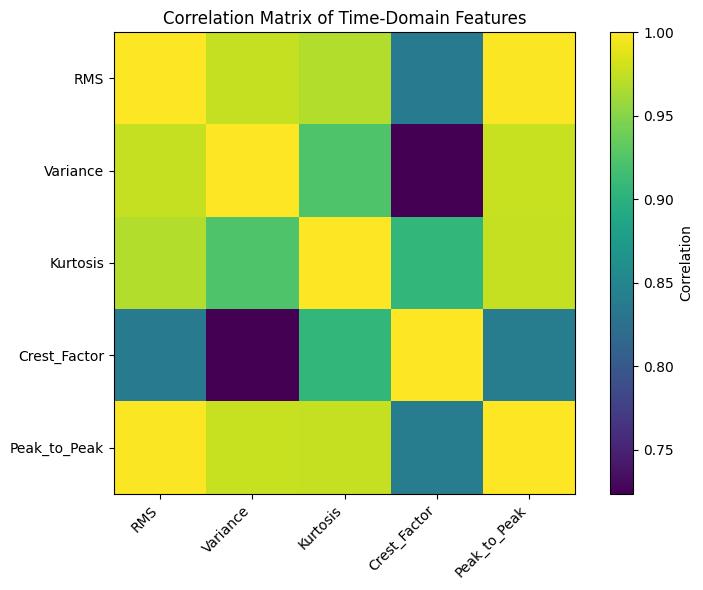

In [8]:
plt.figure(
    figsize=(8, 6)
)

plt.imshow(
    correlation_matrix,
    interpolation="nearest"
)

plt.xticks(
    range(len(time_features)),
    time_features,
    rotation=45,
    ha="right"
)

plt.yticks(
    range(len(time_features)),
    time_features
)

plt.colorbar(
    label="Correlation"
)

plt.title(
    "Correlation Matrix of Time-Domain Features"
)

plt.tight_layout()

plt.savefig(
    FIGURE_PATH
    / "feature_correlation.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

In [9]:
physics_features = [
    "Energy_1x",
    "Energy_2x",
    "Energy_3x",
    "Energy_BPFI",
    "Energy_BPFO",
    "Energy_FTF",
    "Energy_BSF"
]

In [10]:
physics_corr = (
    feature_df[
        physics_features
    ].corr()
)

display(physics_corr)

,Energy_1x,Energy_2x,Energy_3x,Energy_BPFI,Energy_BPFO,Energy_FTF,Energy_BSF
Energy_1x,1.000000,0.931064,0.864877,0.793596,0.977326,0.900820,0.900793
Energy_2x,0.931064,1.000000,0.681869,0.858306,0.976683,0.706284,0.980691
Energy_3x,0.864877,0.681869,1.000000,0.561631,0.749639,0.957274,0.586107
Energy_BPFI,0.793596,0.858306,0.561631,1.000000,0.824126,0.626035,0.822754
Energy_BPFO,0.977326,0.976683,0.749639,0.824126,1.000000,0.791096,0.971284
Energy_FTF,0.900820,0.706284,0.957274,0.626035,0.791096,1.000000,0.631780
Energy_BSF,0.900793,0.980691,0.586107,0.822754,0.971284,0.631780,1.000000


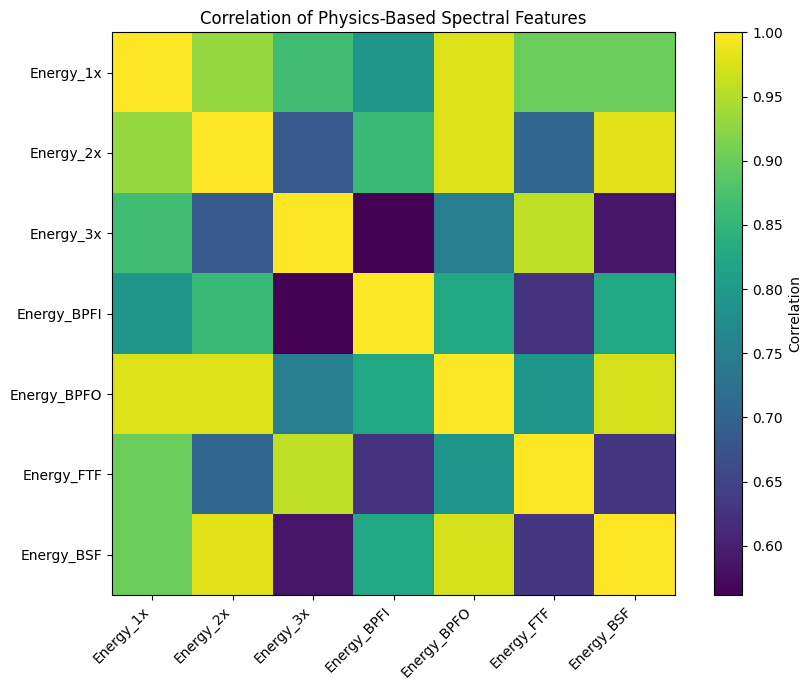

In [11]:
plt.figure(
    figsize=(9, 7)
)

plt.imshow(
    physics_corr,
    interpolation="nearest"
)

plt.xticks(
    range(len(physics_features)),
    physics_features,
    rotation=45,
    ha="right"
)

plt.yticks(
    range(len(physics_features)),
    physics_features
)

plt.colorbar(
    label="Correlation"
)

plt.title(
    "Correlation of Physics-Based Spectral Features"
)

plt.tight_layout()

plt.savefig(
    FIGURE_PATH
    / "physics_feature_correlation.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

In [12]:
feature_columns = [
    "RMS",
    "Variance",
    "Kurtosis",
    "Crest_Factor",
    "Peak_to_Peak",
    "Energy_1x",
    "Energy_2x",
    "Energy_3x",
    "Energy_BPFI",
    "Energy_BPFO",
    "Energy_FTF",
    "Energy_BSF"
]

display(
    feature_df[
        ["class"] + feature_columns
    ].head()
)

,class,RMS,Variance,Kurtosis,Crest_Factor,Peak_to_Peak,Energy_1x,Energy_2x,Energy_3x,Energy_BPFI,Energy_BPFO,Energy_FTF,Energy_BSF
0,Ball,0.138266,0.018884,2.964506,3.802842,1.046245,12.651480,7.261748,16.516354,5924.331644,12.313566,1.602576,19.271154
1,Ball,0.138471,0.019157,2.983638,3.720946,1.030164,4.130463,14.695277,6.011213,1880.497997,5.852975,0.413234,46.279088
2,Ball,0.144331,0.020808,2.724532,3.461846,0.965839,0.962573,12.849932,6.865564,2830.918487,3.090036,0.337600,54.560167
3,Ball,0.154805,0.023953,2.832997,4.030328,1.233532,0.316885,14.019952,5.584360,5597.967603,6.028661,0.474728,49.992032
4,Inner Race,0.289302,0.083467,5.632106,5.477161,2.794696,4.612868,85.396632,9.398079,9877.105213,6.778110,1.214267,74.754989


In [13]:
feature_statistics = (
    feature_df[
        feature_columns
    ].describe().T
)

display(feature_statistics)

,count,mean,std,min,25%,50%,75%,max
RMS,17.0,0.265260,0.212264,0.064424,0.074082,0.154805,0.312346,0.676408
Variance,17.0,0.112622,0.149878,0.003967,0.005353,0.023953,0.097539,0.456391
Kurtosis,17.0,4.641468,2.078425,2.724532,2.925184,2.983638,5.632106,8.053920
Crest_Factor,17.0,4.409673,0.827514,3.461846,3.678552,4.030328,5.209852,5.477161
Peak_to_Peak,17.0,2.499756,2.277683,0.439344,0.520287,1.233532,3.037050,6.760144
Energy_1x,14.0,64.179275,128.480445,0.316885,3.504127,10.200841,34.061255,413.047918
Energy_2x,14.0,117.845967,208.457819,7.261748,14.188783,25.151955,81.606479,671.825264
Energy_3x,14.0,2828.925095,9160.262827,5.584360,6.953728,9.784649,11.454663,34289.766416
Energy_BPFI,14.0,6966.643910,4130.488938,1880.497997,3972.030404,6325.196977,8591.300446,16241.260928
Energy_BPFO,14.0,680.124137,1490.589565,3.090036,6.216023,15.181524,239.038713,4360.307900


In [14]:
class_means = (
    feature_df
    .groupby("class")
    [feature_columns]
    .mean()
)

display(class_means)

,RMS,Variance,Kurtosis,Crest_Factor,Peak_to_Peak,Energy_1x,Energy_2x,Energy_3x,Energy_BPFI,Energy_BPFO,Energy_FTF,Energy_BSF
class,,,,,,,,,,,,
Ball,0.143968,0.020700,2.876419,3.753991,1.068945,4.515350,12.206727,8.744373,4058.428933,6.821309,0.707035,42.525610
Healthy,0.066984,0.004357,2.916736,3.603714,0.462417,361.146375,599.739045,19747.075887,14930.011946,4182.179535,16.809759,3118.173118
Inner Race,0.298149,0.088893,5.443613,5.229344,2.841924,4.708258,81.717070,10.326213,7216.877579,10.556898,1.289894,73.662432
Outer Race,0.601507,0.363601,7.760287,5.253133,6.135073,34.830666,18.667563,8.629302,5642.941201,271.966505,3.491833,58.659199


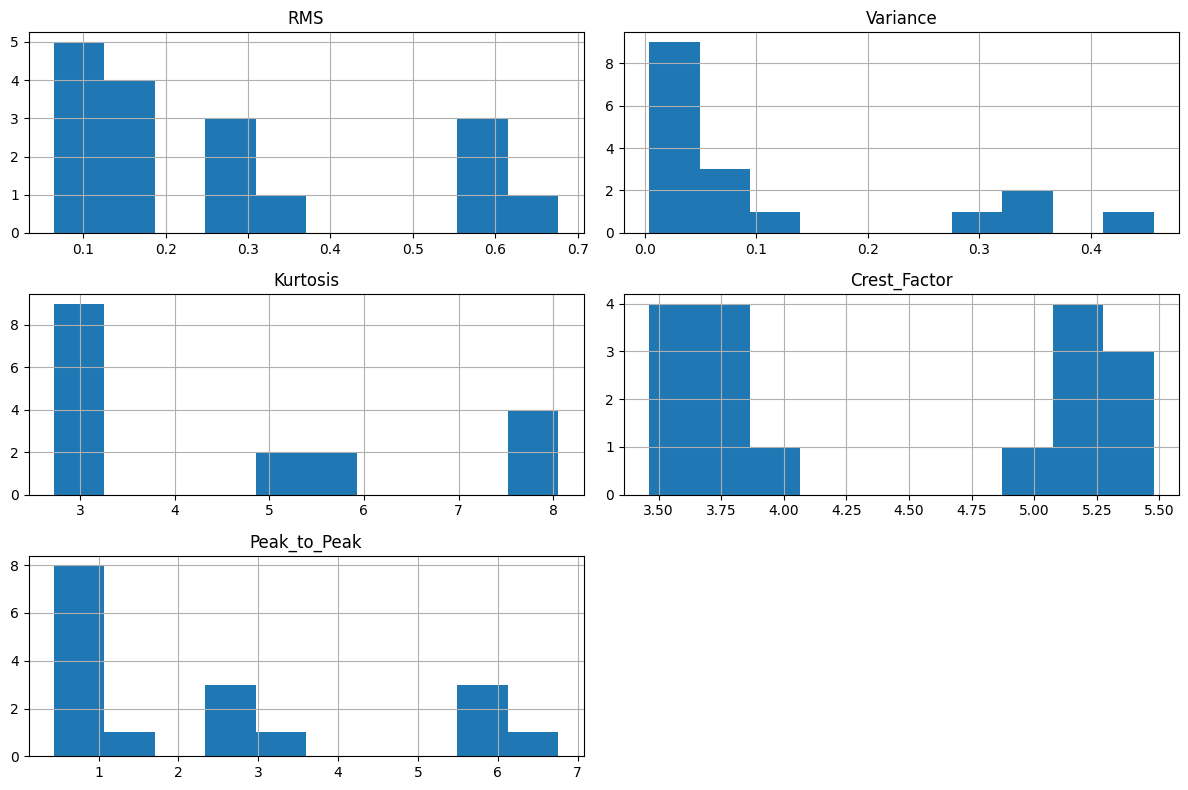

In [15]:
feature_df[
    time_features
].hist(
    figsize=(12, 8),
    bins=10
)

plt.tight_layout()

plt.savefig(
    FIGURE_PATH
    / "time_feature_distributions.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

In [16]:
baseline_features = [
    "RMS",
    "Variance",
    "Kurtosis",
    "Crest_Factor",
    "Peak_to_Peak"
]

In [17]:
X = feature_df[
    baseline_features
].copy()

y = feature_df[
    "class"
].copy()

In [18]:
print(
    "X shape:",
    X.shape
)

print(
    "y shape:",
    y.shape
)

X shape: (17, 5)
y shape: (17,)


In [19]:
print(
    "Missing values:"
)

print(
    X.isnull().sum()
)

Missing values:
RMS             0
Variance        0
Kurtosis        0
Crest_Factor    0
Peak_to_Peak    0
dtype: int64


In [20]:
label_encoder = LabelEncoder()

y_encoded = (
    label_encoder
    .fit_transform(y)
)

print(
    "Classes:"
)

print(
    label_encoder.classes_
)

Classes:
['Ball' 'Healthy' 'Inner Race' 'Outer Race']


In [21]:
class_mapping = {
    class_name: index
    for index, class_name
    in enumerate(
        label_encoder.classes_
    )
}

print(class_mapping)

{'Ball': 0, 'Healthy': 1, 'Inner Race': 2, 'Outer Race': 3}


In [22]:
scaler = StandardScaler()

X_scaled = scaler.fit_transform(
    X
)

print(
    X_scaled[:5]
)

[[-0.61669706 -0.64467006 -0.83167443 -0.75588708 -0.65779355]
 [-0.61569846 -0.64279828 -0.82218592 -0.85789965 -0.66507112]
 [-0.58724492 -0.63144208 -0.95068732 -1.18064189 -0.69418139]
 [-0.53638214 -0.60981336 -0.89689504 -0.47252322 -0.57303561]
 [ 0.116754   -0.20051079  0.49129835  1.32969529  0.1334766 ]]


In [23]:
rf = RandomForestClassifier(
    n_estimators=100,
    random_state=42,
    class_weight="balanced"
)

In [24]:
rf.fit(
    X_scaled,
    y_encoded
)

,n_estimators,100
,criterion,'gini'
,max_depth,None
,min_samples_split,2
,min_samples_leaf,1
,min_weight_fraction_leaf,0.0
,max_features,'sqrt'
,max_leaf_nodes,None
,min_impurity_decrease,0.0
,bootstrap,True
,oob_score,False


In [25]:
y_pred = rf.predict(
    X_scaled
)

In [26]:
training_accuracy = accuracy_score(
    y_encoded,
    y_pred
)

print(
    "Exploratory training accuracy:",
    training_accuracy
)

Exploratory training accuracy: 1.0


In [27]:
importance_df = pd.DataFrame({
    "Feature": baseline_features,
    "Importance": rf.feature_importances_
})

importance_df = (
    importance_df
    .sort_values(
        "Importance",
        ascending=False
    )
)

display(importance_df)

,Feature,Importance
1,Variance,0.266637
0,RMS,0.245467
4,Peak_to_Peak,0.237893
2,Kurtosis,0.136308
3,Crest_Factor,0.113695


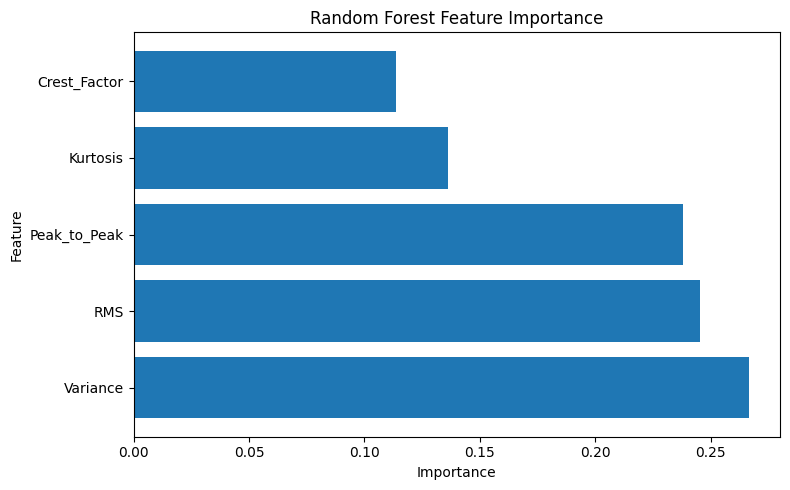

In [28]:
plt.figure(
    figsize=(8, 5)
)

plt.barh(
    importance_df["Feature"],
    importance_df["Importance"]
)

plt.xlabel(
    "Importance"
)

plt.ylabel(
    "Feature"
)

plt.title(
    "Random Forest Feature Importance"
)

plt.tight_layout()

plt.savefig(
    FIGURE_PATH
    / "random_forest_feature_importance.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

In [29]:
baseline_results = pd.DataFrame({
    "Model": [
        "Random Forest"
    ],

    "Features": [
        "RMS, Variance, Kurtosis, Crest Factor, Peak-to-Peak"
    ],

    "Training_Accuracy": [
        training_accuracy
    ],

    "Random_State": [
        42
    ],

    "Estimators": [
        100
    ]
})

display(
    baseline_results
)

,Model,Features,Training_Accuracy,Random_State,Estimators
0,Random Forest,"RMS, Variance, Kurtosis, Crest Factor, Peak-to...",1.0,42,100


In [30]:
baseline_results.to_csv(
    PROCESSED_PATH
    / "baseline_results.csv",
    index=False
)

print(
    "Baseline results saved."
)

Baseline results saved.


In [31]:
feature_statistics.to_csv(
    PROCESSED_PATH
    / "feature_statistics.csv"
)

In [32]:
class_means.to_csv(
    PROCESSED_PATH
    / "class_feature_means.csv"
)

In [33]:
print(
    "Feature dataset:",
    feature_df.shape
)

print(
    "\nClass distribution:"
)

print(
    feature_df["class"].value_counts()
)

print(
    "\nBaseline features:"
)

print(
    baseline_features
)

print(
    "\nSaved figures:"
)

for file in FIGURE_PATH.glob("*.png"):
    print(file.name)

Feature dataset: (17, 16)

Class distribution:
class
Healthy       5
Ball          4
Inner Race    4
Outer Race    4
Name: count, dtype: int64

Baseline features:
['RMS', 'Variance', 'Kurtosis', 'Crest_Factor', 'Peak_to_Peak']

Saved figures:
boxplot_Crest_Factor.png
boxplot_Kurtosis.png
boxplot_Peak_to_Peak.png
boxplot_RMS.png
boxplot_Variance.png
feature_correlation.png
NORMAL_0_fft.png
physics_feature_correlation.png
random_forest_feature_importance.png
time_feature_distributions.png
